In [4]:
import os
import csv
import pandas as pd
import re
import subprocess
import numpy as np
import scipy.stats as stats

new_dir = "/home/jingqi/RNALocateV3.0/Data"
os.chdir(new_dir)
os.getcwd()

'/home/jingqi/RNALocateV3.0/Data'

## I Attract Database solely

### Build databse

In [46]:
db_file = "Raw/Attract/ATtRACT_db.txt"
pwm_file = "Raw/Attract/pwm.txt"
output_meme = "Raw/Attract/ATtRACT_database.meme"

print("Loading ATtRACT metadata...")
df_db = pd.read_csv(db_file, sep="\t")

# Keep everything
matrix_to_protein = dict(zip(df_db['Matrix_id'].astype(str), df_db['Gene_name']))
print(f"Found {len(matrix_to_protein)} unique matrices.")

with open(pwm_file, "r") as f_in, open(output_meme, "w") as f_out:
    
    # The universal standard header
    f_out.write("MEME version 4\n\n")
    f_out.write("ALPHABET= ACGT\n\n")
    f_out.write("strands= + -\n\n")
    f_out.write("Background letter frequencies:\n")
    f_out.write("A 0.25 C 0.25 G 0.25 T 0.25\n\n")
    
    current_matrix_id = None
    current_matrix = []
    
    for line in f_in:
        line = line.strip()
        if line.startswith(">"):
            if current_matrix_id in matrix_to_protein:
                protein = matrix_to_protein[current_matrix_id]
                f_out.write(f"MOTIF {current_matrix_id} {protein}\n")
                f_out.write(f"letter-probability matrix: alength= 4 w= {len(current_matrix)} nsites= 20 E= 0\n")
                for row in current_matrix:
                    f_out.write("\t".join(row) + "\n")
                f_out.write("\n")
            
            current_matrix_id = line[1:].split()[0]
            current_matrix = []
        elif line and current_matrix_id in matrix_to_protein:
            current_matrix.append(line.split())

    # Write the very last motif
    if current_matrix_id in matrix_to_protein:
        protein = matrix_to_protein[current_matrix_id]
        f_out.write(f"MOTIF {current_matrix_id} {protein}\n")
        f_out.write(f"letter-probability matrix: alength= 4 w= {len(current_matrix)} nsites= 20 E= 0\n")
        for row in current_matrix:
            f_out.write("\t".join(row) + "\n")

print(f"Database compiled at: {output_meme}")

Loading ATtRACT metadata...
Found 1583 unique matrices.
Database compiled at: Raw/Attract/ATtRACT_database.meme


### 1. Run TOMTOM

In [48]:
label_names = [
    "chromatin", "cytoplasm", "cytosol", "ER", "extracellular", 
    "membrane", "mitochondrion", "nucleolus", "nucleoplasm", "nucleus", "ribosome"
]

databases = {
    "ATtRACT": "Raw/Attract/ATtRACT_database.meme"
}

tomtom_path = "/home/jingqi/miniconda3/envs/rnalocate_old/bin/tomtom"
markov_path = "/home/jingqi/miniconda3/envs/rnalocate_old/bin/fasta-get-markov"
meme_output_dir = "MEME_New/meme_results"
attract_output_dir = "ATTRACT/attract_results"


In [49]:
for class_name in label_names:
    meme_results = f"{meme_output_dir}/{class_name}_positive/meme.txt"
    if not os.path.exists(meme_results):
        print(f"  WARNING: File not found: {meme_results}")
        continue
        
    print(f" TOMTOM: {class_name}")
        
    for db_name, db_path in databases.items():
        db_path_expanded = os.path.expanduser(db_path)
            
        attract_out = f"{attract_output_dir}/{db_name}/{class_name}"
        os.makedirs(attract_out, exist_ok=True)
            
        tomtom_cmd = [
            tomtom_path,
            "-oc", attract_out,
            "-thresh", "1.0",
            "-evalue",
            "-no-ssc",      
            "-min-overlap", "4",
            meme_results,
            db_path_expanded
        ]
            
        try:
            subprocess.run(tomtom_cmd, check=True, capture_output=True)
        except subprocess.CalledProcessError as e:
            print(f"  Error in {db_name}: {e.stderr.decode()[:100]}")

print("\n TOMTOM complete")

 TOMTOM: chromatin
 TOMTOM: cytoplasm
 TOMTOM: cytosol
 TOMTOM: ER
 TOMTOM: extracellular
 TOMTOM: membrane
 TOMTOM: mitochondrion
 TOMTOM: nucleolus
 TOMTOM: nucleoplasm
 TOMTOM: nucleus
 TOMTOM: ribosome

 TOMTOM complete


### 2.Filter the result

In [84]:
MEME_E_VALUE_THRESH = 0.05
MIN_ABUNDANCE_PERCENT = 0.20  
TOMTOM_Q_VALUE_THRESH = 0.05
TOTAL_SEQS = 150

db_file = "Raw/Attract/ATtRACT_db.txt"
meme_output_dir = "MEME_New/meme_results"
attract_base_dir = "ATTRACT/attract_results/ATtRACT"
output_profile_csv = "ATTRACT/Protein_Binding_Profiles.csv"

label_names = [
    "chromatin", "cytoplasm", "cytosol", "ER", "extracellular", 
    "membrane", "mitochondrion", "nucleolus", "nucleoplasm", "nucleus", "ribosome"
]

print("Loading ATtRACT metadata for protein profiling...")
df_db = pd.read_csv(db_file, sep="\t")
df_db['Gene_name'] = df_db['Gene_name'].astype(str).str.upper() 
matrix_to_protein = dict(zip(df_db['Matrix_id'].astype(str), df_db['Gene_name']))

all_valid_hits = []

for class_name in label_names:
    meme_file = f"{meme_output_dir}/{class_name}_positive/meme.txt"
    tomtom_file = f"{attract_base_dir}/{class_name}/tomtom.txt"
    
    if not os.path.exists(tomtom_file):
        tomtom_file = f"{attract_base_dir}/{class_name}/tomtom.tsv"
        
    if not os.path.exists(meme_file) or not os.path.exists(tomtom_file):
        continue

    # Extract Valid MEME Motifs, applying E-value and Abundance Gates
    valid_query_motifs = {}
    with open(meme_file, 'r') as f:
        content = f.read()
        blocks = re.split(r'MOTIF\s+', content)[1:]
        
        for block in blocks:
            lines = block.strip().split('\n')
            motif_id = lines[0].split()[0]
            meta_line = next((line for line in lines if "letter-probability matrix:" in line), None)
            
            if meta_line:
                sites_match = re.search(r'nsites=\s*(\d+)', meta_line)
                e_val_match = re.search(r'E=\s*([^\s]+)', meta_line)
                
                if sites_match and e_val_match:
                    sites = int(sites_match.group(1))
                    e_val = float(e_val_match.group(1))
                    abundance = sites / TOTAL_SEQS
                    
                    # ENFORCING BOTH GATES
                    if e_val < MEME_E_VALUE_THRESH and abundance >= MIN_ABUNDANCE_PERCENT:
                        valid_query_motifs[motif_id] = sites

    # Extract Valid TOMTOM Hits for Surviving Motifs
    try:
        df_tomtom = pd.read_csv(tomtom_file, sep='\t')
        df_tomtom.columns = df_tomtom.columns.str.replace('#', '', regex=False).str.strip().str.replace(' ', '_')
    except Exception:
        continue
        
    if df_tomtom.empty or 'Query_ID' not in df_tomtom.columns:
        continue

    for _, row in df_tomtom.iterrows():
        if str(row.get('Orientation', '')) == '-':
            continue
            
        query_motif = str(row['Query_ID'])
        
        # Immediate kill switch if the motif didn't pass Phase 1
        if query_motif not in valid_query_motifs:
            continue
            
        try:
            q_val = float(row.get('q-value', 1.0))
        except ValueError:
            continue
            
        # Enforcing TOMTOM Gate
        if q_val < TOMTOM_Q_VALUE_THRESH:
            target_id = str(row.get('Target_ID', ''))
            protein_name = matrix_to_protein.get(target_id, target_id)
            hit_counts = valid_query_motifs[query_motif]
            
            all_valid_hits.append({
                'Class': class_name,
                'Protein_Name': protein_name,
                'Target_Matrix': target_id,
                'Counts': hit_counts,
                'q-value': q_val
            })

# Aggregate and Profile the Proteins
df_hits = pd.DataFrame(all_valid_hits)

if not df_hits.empty:
    # Calculate the total binding events (counts) for each protein in each class
    protein_totals = df_hits.groupby(['Class', 'Protein_Name'])['Counts'].sum().reset_index()
    protein_totals.rename(columns={'Counts': 'Total_Protein_Events'}, inplace=True)
    
    # Merge the totals back to calculate internal proportions
    df_hits = pd.merge(df_hits, protein_totals, on=['Class', 'Protein_Name'])
    df_hits['Proportion'] = (df_hits['Counts'] / df_hits['Total_Protein_Events']) * 100
    
    # Format a clean string for the matrix breakdown (e.g., "M112 (80.0%)")
    df_hits['Breakdown_String'] = df_hits.apply(
        lambda x: f"{x['Target_Matrix']} ({x['Proportion']:.1f}%)", axis=1
    )
    
    # Group everything together into the final profile
    df_profiles = df_hits.groupby(['Class', 'Protein_Name']).agg(
        Total_Binding_Events=('Total_Protein_Events', 'first'),
        Unique_Matrices_Used=('Target_Matrix', 'nunique'),
        Best_q_value=('q-value', 'min'),
        Matrix_Profile=('Breakdown_String', lambda x: " | ".join(sorted(set(x))))
    ).reset_index()
    
    # Sort by Class, then by Total Binding Events (descending)
    df_profiles = df_profiles.sort_values(by=['Class', 'Total_Binding_Events'], ascending=[True, False])
    
    os.makedirs(os.path.dirname(output_profile_csv), exist_ok=True)
    df_profiles.to_csv(output_profile_csv, index=False)
    
    print(f"Protein Profiling Complete! Generated {len(df_profiles)} unique protein profiles.")
    print(df_profiles.sort_values(by='Total_Binding_Events', ascending=False).head(5).to_string())
else:
    print("No valid hits found to profile.")

Loading ATtRACT metadata for protein profiling...
Protein Profiling Complete! Generated 389 unique protein profiles.
         Class Protein_Name  Total_Binding_Events  Unique_Matrices_Used  Best_q_value                                                                                                                                                                         Matrix_Profile
270  nucleolus       HNRNPK                  1329                    10      0.003593                                      1026 (10.4%) | 1034 (10.4%) | 1036 (10.4%) | 1038 (6.5%) | 1040 (10.4%) | 1041 (10.4%) | 1043 (10.4%) | 1044 (10.4%) | 1045 (10.4%) | s61 (10.4%)
199   membrane        PCBP1                  1186                    10      0.006032                                                      748 (11.2%) | 749 (11.2%) | 762 (9.4%) | 764 (9.4%) | 765 (9.5%) | 770 (9.4%) | 771 (9.4%) | 772 (9.5%) | 775 (9.5%) | 93 (11.2%)
121  cytoplasm        PCBP1                  1153                     9     

## II Add Attract and CISPBR up and cut re dundancy

In [66]:
## Strip away the computationally inferred motifs in CISBP
## Pool CISBP with ATTRACT
## Running hierarchy clustering to merge the similar matrices

from scipy.cluster.hierarchy import linkage, fcluster
from scipy.spatial.distance import pdist

attract_db_file = "Raw/Attract/ATtRACT_db.txt"
attract_pwm_file = "Raw/Attract/pwm.txt"
cisbp_meme_file = "/home/jingqi/meme_db/motif_databases/CISBP-RNA/Mus_musculus.meme"
output_meme = "Raw/Attract/CISPBR+ATTRACT.meme"

### Load Attract and cluster

In [60]:
protein_groups = {}

print("Ingesting ATtRACT arrays...")
df_attract = pd.read_csv(attract_db_file, sep="\t")
df_attract['Gene_name'] = df_attract['Gene_name'].astype(str).str.upper()
attract_map = dict(zip(df_attract['Matrix_id'].astype(str), df_attract['Gene_name']))

current_matrix_id = None
current_matrix = []

with open(attract_pwm_file, "r") as f:
    for line in f:
        line = line.strip()
        if line.startswith(">"):
            if current_matrix_id and len(current_matrix) > 0:
                prot = attract_map.get(current_matrix_id)
                if prot:
                    protein_groups.setdefault(prot, []).append((current_matrix_id, np.array(current_matrix, dtype=float)))
            current_matrix_id = line[1:].split()[0]
            current_matrix = []
        elif line:
            current_matrix.append(line.split())
            
if current_matrix_id and len(current_matrix) > 0:
    prot = attract_map.get(current_matrix_id)
    if prot:
        protein_groups.setdefault(prot, []).append((current_matrix_id, np.array(current_matrix, dtype=float)))
print(f"ATtRACT load complete. Current proteins tracked: {len(protein_groups)}")

Ingesting ATtRACT arrays...
ATtRACT load complete. Current proteins tracked: 328


### Ingest CISBPR

In [61]:
print("Unpacking CISBP-RNA MEME file...")
cisbp_count = 0

with open(cisbp_meme_file, 'r') as f:
    reading_matrix = False
    current_prot = None
    current_motif_id = None
    current_matrix = []
    
    for line in f:
        line = line.strip()
        if line.startswith("MOTIF"):
            parts = line.split()
            current_motif_id = parts[1]
            if len(parts) > 2:
                current_prot = parts[2].upper()
            else:
                current_prot = current_motif_id.upper()
        elif line.startswith("letter-probability matrix:"):
            reading_matrix = True
            current_matrix = []
        elif reading_matrix:
            if not line or line.startswith("MOTIF") or line.startswith("URL"):
                if current_prot and len(current_matrix) > 0:
                    protein_groups.setdefault(current_prot, []).append((current_motif_id, np.array(current_matrix, dtype=float)))
                    cisbp_count += 1
                reading_matrix = False
                
                if line.startswith("MOTIF"):
                    parts = line.split()
                    current_motif_id = parts[1]
                    current_prot = parts[2].upper() if len(parts) > 2 else current_motif_id.upper()
            else:
                try:
                    row_vals = [float(x) for x in line.split()]
                    if len(row_vals) == 4:
                        current_matrix.append(row_vals)
                except ValueError:
                    pass
                    
    if reading_matrix and current_prot and len(current_matrix) > 0:
        protein_groups.setdefault(current_prot, []).append((current_motif_id, np.array(current_matrix, dtype=float)))
        cisbp_count += 1

print(f"Successfully extracted {cisbp_count} matrices from CISBP-RNA.")
print(f"Combined unique proteins now tracked: {len(protein_groups)}")

Unpacking CISBP-RNA MEME file...
Successfully extracted 93 matrices from CISBP-RNA.
Combined unique proteins now tracked: 415


### Merge matrices

In [ ]:
## Instead of padding shorter ones into the length of the longest one, here we only
## compare the most relevant part. We slide all matrices against each other, record 
## the smallest distance. In the distance matirx, we use hierarchical clustering. 
## Within the cluster, we slide the shorter ones aginst the single longest one to lock
## their position.

## When calculating the distance, we cannot simply add the noise in each position
## together, otherwise the longer ones easily sit too far. We normalized the distance
## by dividing the square root of N, which is the number of sequences in each position.

## Euclidian distance measures the absolute distance. Even two matrices share the
## similar structural trend, ED can distinguish them. So here we use pearson
## correlation. Flatten each matrix into 1D string. Pearson distance = 1-r, (0,2)

## As for merging, sfor each position we may have
## different combinations to average. If some positions don't have anything to avergae,
## keep them as they are in the longest one.

In [78]:
import warnings
from scipy.cluster.hierarchy import linkage, fcluster

CLUSTER_THRESHOLD = 0.25

def calculate_pearson_distance(a, b):
    a_flat = a.flatten()
    b_flat = b.flatten()
    a_centered = a_flat - np.mean(a_flat)
    b_centered = b_flat - np.mean(b_flat)
    norm_a = np.linalg.norm(a_centered)
    norm_b = np.linalg.norm(b_centered)
    if norm_a == 0 or norm_b == 0:
        return 1.0
    corr = np.dot(a_centered, b_centered) / (norm_a * norm_b)
    return 1.0 - corr

print("Executing all-against-all Pearson correlation clustering...")
consensus_database = []

for protein, mat_list in protein_groups.items():
    num_mats = len(mat_list)
    if num_mats == 1:
        consensus_database.append((protein, 1, mat_list[0][1]))
        continue
        
    condensed_dist = []
    for i in range(num_mats):
        mat_i = mat_list[i][1]
        len_i = mat_i.shape[0]
        for j in range(i + 1, num_mats):
            mat_j = mat_list[j][1]
            len_j = mat_j.shape[0]
            
            min_dist = float('inf')
            
            if len_i >= len_j:
                longer, shorter = mat_i, mat_j
                len_l, len_s = len_i, len_j
            else:
                longer, shorter = mat_j, mat_i
                len_l, len_s = len_j, len_i
                
            for offset in range(len_l - len_s + 1):
                overlap_long = longer[offset : offset + len_s]
                dist = calculate_pearson_distance(shorter, overlap_long)
                if dist < min_dist:
                    min_dist = dist
                    
            condensed_dist.append(min_dist)
            
    try:
        Z = linkage(condensed_dist, method='average')
        clusters = fcluster(Z, t=CLUSTER_THRESHOLD, criterion='distance')
    except ValueError:
        clusters = np.ones(num_mats, dtype=int)
        
    unique_clusters = np.unique(clusters)
    
    for c_id in unique_clusters:
        cluster_indices = np.where(clusters == c_id)[0]
        cluster_mats = [mat_list[idx][1] for idx in cluster_indices]
        
        if len(cluster_mats) == 1:
            consensus_database.append((protein, c_id, cluster_mats[0]))
            continue
            
        local_baseline_idx = max(range(len(cluster_mats)), key=lambda idx: cluster_mats[idx].shape[0])
        local_baseline = cluster_mats[local_baseline_idx]
        max_len = local_baseline.shape[0]
        
        aligned_matrices = []
        for mat in cluster_mats:
            mat_len = mat.shape[0]
            if mat_len == max_len:
                best_offset = 0
            else:
                min_dist = float('inf')
                best_offset = 0
                for offset in range(max_len - mat_len + 1):
                    overlap = local_baseline[offset : offset + mat_len]
                    dist = calculate_pearson_distance(mat, overlap)
                    if dist < min_dist:
                        min_dist = dist
                        best_offset = offset
                        
            padded_mat = np.full((max_len, 4), np.nan)
            padded_mat[best_offset : best_offset + mat_len] = mat
            aligned_matrices.append(padded_mat)
            
        with warnings.catch_warnings():
            warnings.simplefilter("ignore", category=RuntimeWarning)
            raw_consensus = np.nanmean(aligned_matrices, axis=0)
            
        trimmed_consensus = raw_consensus[~np.isnan(raw_consensus).all(axis=1)]
        row_sums = trimmed_consensus.sum(axis=1)[:, np.newaxis]
        final_consensus = np.divide(trimmed_consensus, row_sums, out=np.zeros_like(trimmed_consensus), where=row_sums!=0)
        
        consensus_database.append((protein, c_id, final_consensus))

print(f"Pearson alignment complete. Generated {len(consensus_database)} finalized consensus matrices.")

Executing all-against-all Pearson correlation clustering...
Pearson alignment complete. Generated 694 finalized consensus motifs.


### MEME Compilation

In [79]:
with open(output_meme, "w") as f_out:
    f_out.write("MEME version 4\n\nALPHABET= ACGT\n\nstrands= + -\n\n")
    f_out.write("Background letter frequencies:\nA 0.25000 C 0.25000 G 0.25000 T 0.25000\n\n")
    
    for protein, cluster_id, matrix in consensus_database:
        motif_name = f"{protein}_C{cluster_id}"
        f_out.write(f"MOTIF {motif_name} {protein}\n")
        f_out.write(f"letter-probability matrix: alength= 4 w= {matrix.shape[0]} nsites= 20 E= 0\n")
        for row in matrix:
            formatted_row = "\t".join([f"{val:.6f}" for val in row])
            f_out.write(formatted_row + "\n")
        f_out.write("\n")

print(f"Master database compiled at: {output_meme}")

Master database compiled at: Raw/Attract/CISPBR+ATTRACT.meme


## 1. Run TOMTOM

In [80]:
label_names = [
    "chromatin", "cytoplasm", "cytosol", "ER", "extracellular", 
    "membrane", "mitochondrion", "nucleolus", "nucleoplasm", "nucleus", "ribosome"
]

databases = {
    "ATtRACT": "Raw/Attract/CISPBR+ATTRACT.meme"
}

tomtom_path = "/home/jingqi/miniconda3/envs/rnalocate_old/bin/tomtom"
markov_path = "/home/jingqi/miniconda3/envs/rnalocate_old/bin/fasta-get-markov"
meme_output_dir = "MEME_New/meme_results"
attract_output_dir = "ATTRACT_3UTR/CISPBR+attract_results"


In [83]:
for class_name in label_names:
    meme_results = f"{meme_output_dir}/{class_name}_positive/meme.txt"
    if not os.path.exists(meme_results):
        print(f"  WARNING: File not found: {meme_results}")
        continue
        
    print(f" TOMTOM: {class_name}")
        
    for db_name, db_path in databases.items():
        db_path_expanded = os.path.expanduser(db_path)
            
        attract_out = f"{attract_output_dir}/{db_name}/{class_name}"
        os.makedirs(attract_out, exist_ok=True)
            
        tomtom_cmd = [
            tomtom_path,
            "-oc", attract_out,
            "-thresh", "1.0",
            "-evalue",
            "-no-ssc",      
            "-min-overlap", "4",
            meme_results,
            db_path_expanded
        ]
            
        try:
            subprocess.run(tomtom_cmd, check=True, capture_output=True)
        except subprocess.CalledProcessError as e:
            print(f"  Error in {db_name}: {e.stderr.decode()[:100]}")

print("\n TOMTOM complete")

 TOMTOM: chromatin
 TOMTOM: cytoplasm
 TOMTOM: cytosol
 TOMTOM: ER
 TOMTOM: extracellular
 TOMTOM: membrane
 TOMTOM: mitochondrion
 TOMTOM: nucleolus
 TOMTOM: nucleoplasm
 TOMTOM: nucleus
 TOMTOM: ribosome

 TOMTOM complete


## 2.Filter the result

In [94]:
MEME_E_VALUE_THRESH = 0.05
MIN_ABUNDANCE_PERCENT = 0.20  
TOMTOM_Q_VALUE_THRESH = 0.05
TOTAL_SEQS = 150

db_file = "Raw/Attract/ATtRACT_db.txt"
meme_output_dir = "MEME_3UTR/meme_results"
attract_base_dir = "ATTRACT_3UTR/CISPBR+attract_results/ATtRACT"

output_profile_csv = "ATTRACT_3UTR/CISPBR+attract_results/Protein_Binding_Profiles.csv"
output_matched_csv = "ATTRACT_3UTR/CISPBR+attract_results/Motifs_Annotated_Matched.csv"
output_orphans_csv = "ATTRACT_3UTR/CISPBR+attract_results/Motifs_Unannotated_Orphans.csv"

### visualization

In [51]:
import matplotlib.pyplot as plt
import seaborn as sns

label_names = [
    "chromatin", "cytoplasm", "cytosol", "ER", "extracellular", 
    "membrane", "mitochondrion", "nucleolus", "nucleoplasm", "nucleus", "ribosome"
]


TOTAL_SEQS = 150
meme_output_dir = "MEME_3UTR/meme_results"
attract_base_dir = "ATTRACT_3UTR/CISPBR+attract_results/ATtRACT"

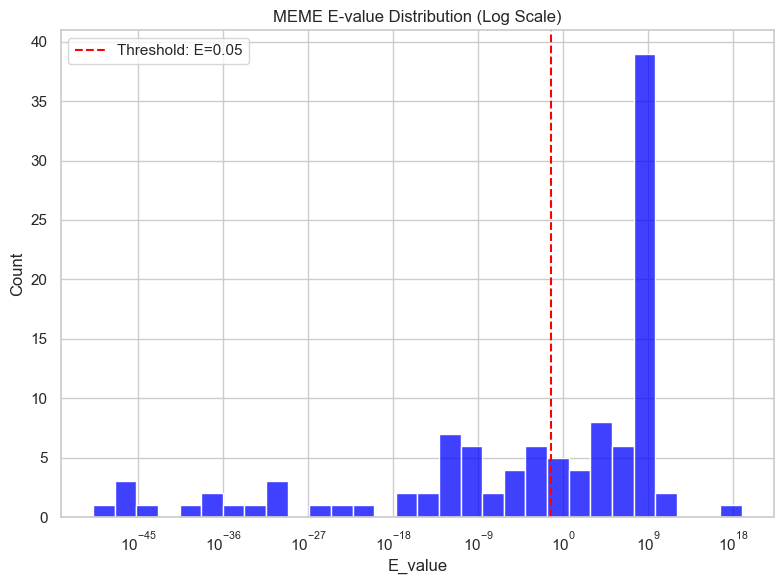

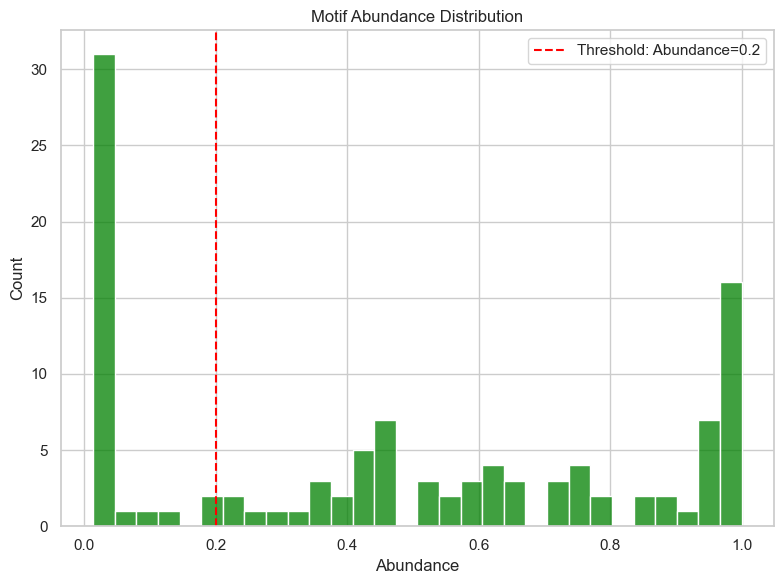

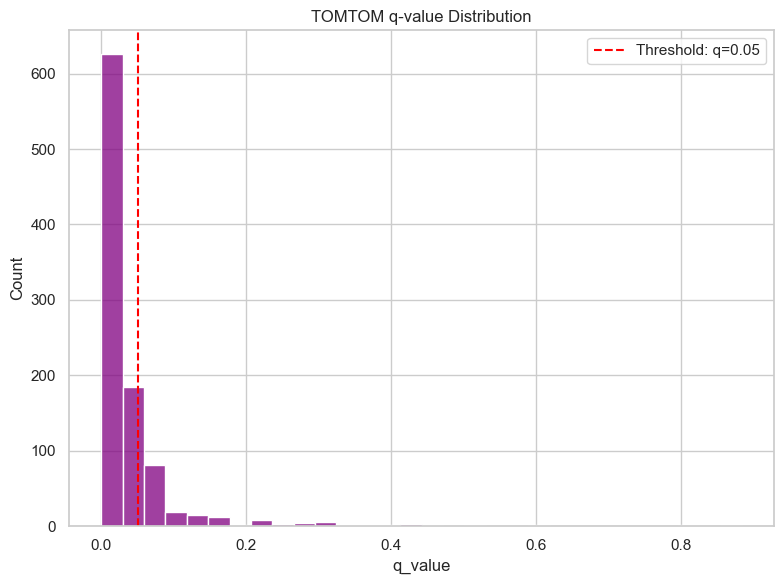

In [53]:
raw_meme_data = []
raw_tomtom_data = []

for class_name in label_names:
    meme_file = f"{meme_output_dir}/{class_name}_positive/meme.txt"
    tomtom_file = f"{attract_base_dir}/{class_name}/tomtom.txt"
    
    if not os.path.exists(tomtom_file):
        tomtom_file = f"{attract_base_dir}/{class_name}/tomtom.tsv"
        
    if not os.path.exists(meme_file):
        continue

    with open(meme_file, 'r') as f:
        content = f.read()
        blocks = re.split(r'MOTIF\s+', content)[1:]
        
        for block in blocks:
            lines = block.strip().split('\n')
            motif_id = lines[0].split()[0].replace('motif_', '')
            
            meta_line = next((line for line in lines if "letter-probability matrix:" in line), None)            
            if meta_line:
                sites_match = re.search(r'nsites=\s*(\d+)', meta_line)
                e_val_match = re.search(r'E=\s*([^\s]+)', meta_line)
                
                if sites_match and e_val_match:
                    sites = int(sites_match.group(1))
                    e_val = float(e_val_match.group(1))
                    abundance = sites / TOTAL_SEQS
                    
                    raw_meme_data.append({
                        'Class': class_name,
                        'Motif': motif_id,
                        'E_value': e_val,
                        'Abundance': abundance
                    })

    if os.path.exists(tomtom_file):
        try:
            df_tomtom = pd.read_csv(tomtom_file, sep='\t')
            df_tomtom.columns = df_tomtom.columns.str.replace('#', '', regex=False).str.strip().str.replace(' ', '_')
            
            if not df_tomtom.empty and 'Query_ID' in df_tomtom.columns:
                for _, row in df_tomtom.iterrows():
                    if str(row.get('Orientation', '')) == '-':
                        continue
                    
                    try:
                        q_val = float(row.get('q-value', 1.0))
                        raw_tomtom_data.append({
                            'Class': class_name,
                            'Query_Motif': str(row['Query_ID']).replace('motif_', ''),
                            'q_value': q_val
                        })
                    except ValueError:
                        continue
        except Exception:
            pass

df_meme = pd.DataFrame(raw_meme_data)
df_tomtom = pd.DataFrame(raw_tomtom_data)

sns.set_theme(style="whitegrid")

plt.figure(figsize=(8, 6))
sns.histplot(data=df_meme, x='E_value', log_scale=(True, False), bins=30, color='blue')
plt.title('MEME E-value Distribution (Log Scale)')
plt.axvline(0.05, color='red', linestyle='--', label='Threshold: E=0.05')
plt.legend()
plt.tight_layout()
plt.show()

plt.figure(figsize=(8, 6))
sns.histplot(data=df_meme, x='Abundance', bins=30, color='green')
plt.title('Motif Abundance Distribution')
plt.axvline(0.20, color='red', linestyle='--', label='Threshold: Abundance=0.2')
plt.legend()
plt.tight_layout()
plt.show()

plt.figure(figsize=(8, 6))
sns.histplot(data=df_tomtom, x='q_value', bins=30, color='purple')
plt.title('TOMTOM q-value Distribution')
plt.axvline(0.05, color='red', linestyle='--', label='Threshold: q=0.05')
plt.legend()
plt.tight_layout()
plt.show()

### Binding events

In [90]:
print("Loading ATtRACT metadata for protein profiling...")
df_db = pd.read_csv(db_file, sep="\t")
df_db['Gene_name'] = df_db['Gene_name'].astype(str).str.upper() 
matrix_to_protein = dict(zip(df_db['Matrix_id'].astype(str), df_db['Gene_name']))

all_valid_hits = []

for class_name in label_names:
    meme_file = f"{meme_output_dir}/{class_name}_positive/meme.txt"
    tomtom_file = f"{attract_base_dir}/{class_name}/tomtom.txt"
    
    if not os.path.exists(tomtom_file):
        tomtom_file = f"{attract_base_dir}/{class_name}/tomtom.tsv"
        
    if not os.path.exists(meme_file) or not os.path.exists(tomtom_file):
        continue

    # E-value and Abundance to MEME
    valid_query_motifs = {}
    with open(meme_file, 'r') as f:
        content = f.read()
        blocks = re.split(r'MOTIF\s+', content)[1:]
        
        for block in blocks:
            lines = block.strip().split('\n')
            raw_motif_id = lines[0].split()[0]
            # Normalize the MEME ID
            motif_id = raw_motif_id.replace('motif_', '')
            
            meta_line = next((line for line in lines if "letter-probability matrix:" in line), None)            
            if meta_line:
                sites_match = re.search(r'nsites=\s*(\d+)', meta_line)
                e_val_match = re.search(r'E=\s*([^\s]+)', meta_line)
                
                if sites_match and e_val_match:
                    sites = int(sites_match.group(1))
                    e_val = float(e_val_match.group(1))
                    abundance = sites / TOTAL_SEQS
                    
                    # ENFORCING BOTH GATES
                    if e_val < MEME_E_VALUE_THRESH and abundance >= MIN_ABUNDANCE_PERCENT:
                        valid_query_motifs[motif_id] = sites

    # Extract Valid TOMTOM Hits
    try:
        df_tomtom = pd.read_csv(tomtom_file, sep='\t')
        df_tomtom.columns = df_tomtom.columns.str.replace('#', '', regex=False).str.strip().str.replace(' ', '_')
    except Exception:
        continue
        
    if df_tomtom.empty or 'Query_ID' not in df_tomtom.columns:
        continue

    for _, row in df_tomtom.iterrows():
        if str(row.get('Orientation', '')) == '-':
            continue
            
        # Normalize the TOMTOM ID
        query_motif = str(row['Query_ID']).replace('motif_', '')
        
        # Immediate kill switch if the motif didn't pass Phase 1
        if query_motif not in valid_query_motifs:
            continue
            
        try:
            q_val = float(row.get('q-value', 1.0))
        except ValueError:
            continue
            
        # Enforcing TOMTOM Gate
        if q_val < TOMTOM_Q_VALUE_THRESH:
            target_id = str(row.get('Target_ID', ''))
            protein_name = matrix_to_protein.get(target_id, target_id)
            hit_counts = valid_query_motifs[query_motif]
            
            all_valid_hits.append({
                'Class': class_name,
                'Protein_Name': protein_name,
                'Target_Matrix': target_id,
                'Counts': hit_counts,
                'q-value': q_val
            })

# Aggregate and Profile the Proteins
df_hits = pd.DataFrame(all_valid_hits)

if not df_hits.empty:
    # Calculate the total binding events (counts) for each protein in each class
    protein_totals = df_hits.groupby(['Class', 'Protein_Name'])['Counts'].sum().reset_index()
    protein_totals.rename(columns={'Counts': 'Total_Protein_Events'}, inplace=True)
    
    # Merge the totals back to calculate internal proportions
    df_hits = pd.merge(df_hits, protein_totals, on=['Class', 'Protein_Name'])
    df_hits['Proportion'] = (df_hits['Counts'] / df_hits['Total_Protein_Events']) * 100
    
    # Format a clean string for the matrix breakdown (e.g., "M112 (80.0%)")
    df_hits['Breakdown_String'] = df_hits.apply(
        lambda x: f"{x['Target_Matrix']} ({x['Proportion']:.1f}%)", axis=1
    )
    
    # Group everything together into the final profile
    df_profiles = df_hits.groupby(['Class', 'Protein_Name']).agg(
        Total_Binding_Events=('Total_Protein_Events', 'first'),
        Unique_Matrices_Used=('Target_Matrix', 'nunique'),
        Best_q_value=('q-value', 'min'),
        Matrix_Profile=('Breakdown_String', lambda x: " | ".join(sorted(set(x))))
    ).reset_index()
    
    # Sort by Class, then by Total Binding Events (descending)
    df_profiles = df_profiles.sort_values(by=['Class', 'Total_Binding_Events'], ascending=[True, False])
    
    os.makedirs(os.path.dirname(output_profile_csv), exist_ok=True)
    df_profiles.to_csv(output_profile_csv, index=False)
    
    print(f"Protein Profiling Complete! Generated {len(df_profiles)} unique protein profiles.")
else:
    print("No valid hits found to profile.")

Loading ATtRACT metadata for protein profiling...
Protein Profiling Complete! Generated 518 unique protein profiles.


### Motifs

In [95]:
print("Loading ATtRACT metadata for motif tracking...")
df_db = pd.read_csv(db_file, sep="\t")
df_db['Gene_name'] = df_db['Gene_name'].astype(str).str.upper() 
matrix_to_protein = dict(zip(df_db['Matrix_id'].astype(str), df_db['Gene_name']))

matched_motifs = []
orphan_motifs = []

for class_name in label_names:
    meme_file = f"{meme_output_dir}/{class_name}_positive/meme.txt"
    tomtom_file = f"{attract_base_dir}/{class_name}/tomtom.txt"
    
    if not os.path.exists(tomtom_file):
        tomtom_file = f"{attract_base_dir}/{class_name}/tomtom.tsv"
        
    if not os.path.exists(meme_file):
        continue

    # Parse MEME 
    valid_query_motifs = {}
    with open(meme_file, 'r') as f:
        content = f.read()
        blocks = re.split(r'MOTIF\s+', content)[1:]
        
        for block in blocks:
            lines = block.strip().split('\n')
            motif_id = lines[0].split()[0]
            motif_num = motif_id.replace('motif_', '') if 'motif_' in motif_id else motif_id
            
            meta_line = next((line for line in lines if "letter-probability matrix:" in line), None)
            
            if meta_line:
                sites_match = re.search(r'nsites=\s*(\d+)', meta_line)
                e_val_match = re.search(r'E=\s*([^\s]+)', meta_line)
                
                if sites_match and e_val_match:
                    sites = int(sites_match.group(1))
                    e_val = float(e_val_match.group(1))
                    abundance = sites / TOTAL_SEQS
                    
                    if e_val < MEME_E_VALUE_THRESH and abundance >= MIN_ABUNDANCE_PERCENT:
                        valid_query_motifs[motif_num] = {
                            'abundance_str': f"{abundance*100:.2f}%",
                            'e_val': e_val
                        }

    # Parse TOMTOM to separate Matched vs Orphans
    tomtom_matched_queries = set()
    
    if os.path.exists(tomtom_file):
        try:
            df_tomtom = pd.read_csv(tomtom_file, sep='\t')
            df_tomtom.columns = df_tomtom.columns.str.replace('#', '', regex=False).str.strip().str.replace(' ', '_')
            
            if not df_tomtom.empty and 'Query_ID' in df_tomtom.columns:
                for _, row in df_tomtom.iterrows():
                    if str(row.get('Orientation', '')) == '-':
                        continue
                        
                    raw_query_id = str(row['Query_ID'])
                    query_motif = raw_query_id.replace('motif_', '') if 'motif_' in raw_query_id else raw_query_id
                    
                    if query_motif not in valid_query_motifs:
                        continue
                        
                    try:
                        q_val = float(row.get('q-value', 1.0))
                    except ValueError:
                        continue
                        
                    if q_val < TOMTOM_Q_VALUE_THRESH:
                        target_id = str(row.get('Target_ID', ''))
                        protein_name = matrix_to_protein.get(target_id, target_id)
                        motif_data = valid_query_motifs[query_motif]
                        
                        matched_motifs.append({
                            'Class': class_name,
                            'Query_Motif': query_motif,
                            'Protein_Name': protein_name,
                            'Abundance': motif_data['abundance_str'],
                            'MEME_E_value': motif_data['e_val'],
                            'TOMTOM_q_value': q_val
                        })
                        tomtom_matched_queries.add(query_motif)
        except Exception:
            pass

    #Identify Orphans (Valid in MEME, missed by TOMTOM)
    for q_motif, data in valid_query_motifs.items():
        if q_motif not in tomtom_matched_queries:
            orphan_motifs.append({
                'Class': class_name,
                'Query_Motif': q_motif,
                'Abundance': data['abundance_str'],
                'MEME_E_value': data['e_val'],
                'Status': 'No high-confidence database match'
            })

df_matched = pd.DataFrame(matched_motifs)
df_orphans = pd.DataFrame(orphan_motifs)

os.makedirs(os.path.dirname(output_matched_csv), exist_ok=True)
df_matched.to_csv(output_matched_csv, index=False)
df_orphans.to_csv(output_orphans_csv, index=False)

print(f"Extraction complete. Found {len(df_matched)} matched annotations and {len(df_orphans)} unannotated orphans.")

Loading ATtRACT metadata for motif tracking...
Extraction complete. Found 520 matched annotations and 14 unannotated orphans.


## 3. Run FIMO

In [98]:
matched_csv = "ATTRACT_3UTR/CISPBR+attract_results/Motifs_Annotated_Matched.csv"  
source_meme_db = "Raw/Attract/CISPBR+ATTRACT.meme" 
fasta_sequences = "Raw/3UTR_safe.txt"
fimo_path = "/home/jingqi/miniconda3/envs/rnalocate_old/bin/fimo"

# FIMO requires this file to exist on the disk
custom_meme_db = "ATTRACT/CISPBR+attract_results/Filtered_Motifs_FIMO.meme"
fimo_output_dir = "ATTRACT/FIMO_Results"

FIMO_P_VALUE_THRESH = "1e-4"

# 1. extrace target matrices
df_matched = pd.read_csv(matched_csv)
unique_targets = set(df_matched['Target_Matrix'].dropna().astype(str))
print(f"Targeting {len(unique_targets)} structurally validated matrices...")

# 2. slice master database
with open(source_meme_db, 'r') as f:
    lines = f.readlines()

header_lines = []
motif_blocks = {}
current_motif_id = None
current_block = []

for line in lines:
    if line.startswith("MOTIF"):
        if current_motif_id:
            motif_blocks[current_motif_id] = current_block
        parts = line.split()
        current_motif_id = parts[1] if len(parts) > 1 else None
        current_block = [line]
    elif current_motif_id:
        current_block.append(line)
    else:
        header_lines.append(line)

if current_motif_id:
    motif_blocks[current_motif_id] = current_block

# 3. write the mandatory FIMO input file
os.makedirs(os.path.dirname(custom_meme_db), exist_ok=True)
with open(custom_meme_db, 'w') as f:
    f.writelines(header_lines)
    for target in unique_targets:
        if target in motif_blocks:
            f.writelines(motif_blocks[target])
            f.write("\n")

print(f"Generated required FIMO database: {custom_meme_db}")

# 4. execute FIMO sequence mapping
print(f"Executing FIMO against {fasta_sequences} at p-value < {FIMO_P_VALUE_THRESH}...")

fimo_command = [
    fimo_path,
    "--oc", fimo_output_dir,
    "--thresh", FIMO_P_VALUE_THRESH,
    custom_meme_db,
    fasta_sequences
]

try:
    subprocess.run(fimo_command, capture_output=True, text=True, check=True)
    print(f"FIMO mapping complete. Results successfully written to: {fimo_output_dir}/fimo.tsv")
except subprocess.CalledProcessError as e:
    print(f"FIMO Execution Failed. Error log:\n{e.stderr}")
except FileNotFoundError:
    print("Python cannot locate the 'fimo' command. Ensure MEME Suite is installed and in your system PATH.")

Targeting 98 structurally validated matrices...
Generated required FIMO database: ATTRACT/CISPBR+attract_results/Filtered_Motifs_FIMO.meme
Executing FIMO against Raw/3UTR_safe.txt at p-value < 1e-4...
FIMO mapping complete. Results successfully written to: ATTRACT/FIMO_Results/fimo.tsv


## Process FIMO results

In [37]:
from scipy.stats import combine_pvalues

fimo_txt_file = "ATTRACT_3UTR/FIMO_Results/fimo.txt"
output_dir = "ATTRACT_3UTR/FIMO_Processed"

transcript_level_csv = f"{output_dir}/transcript_level_filtered.csv"
variance_matrix_csv = f"{output_dir}/Isoform_Variance_Matrix.csv"

FIMO_Q_THRESH = 0.05
## TRANSCRIPT_P_THRESH = 1e-10
## Try not filter according to this combined metrics (what if the only one hit is valid??)
TRANSCRIPT_P_THRESH = 1

os.makedirs(output_dir, exist_ok=True)

# 1. parse and filer raw FIOM
print("Parsing raw FIMO output...")

# Explicitly define the columns to bypass FIMO versioning quirks
fimo_cols = [
    "motif_id", "sequence_name", "start", "stop", "strand", 
    "score", "p-value", "q-value", "matched_sequence"
]

# Force pandas to use our column names
fimo_df = pd.read_csv(
    fimo_txt_file, 
    sep='\t', 
    comment='#', 
    header=None, 
    names=fimo_cols
)

# Ensure numeric types (errors='coerce' will safely turn any accidental string headers into NaN)
fimo_df['q-value'] = pd.to_numeric(fimo_df['q-value'], errors='coerce')
fimo_df['p-value'] = pd.to_numeric(fimo_df['p-value'], errors='coerce')

# Drop NA rows (this cleanly removes any string headers and trailing metadata lines)
fimo_df = fimo_df.dropna(subset=['q-value', 'p-value', 'sequence_name', 'motif_id'])

filtered_fimo = fimo_df[fimo_df['q-value'] < FIMO_Q_THRESH].copy()
print(f"Raw scanning events: {len(fimo_df)}")
print(f"High-confidence events (q < {FIMO_Q_THRESH}): {len(filtered_fimo)}")

# 2. FISHER'S combined P-value (TRANCsript LEVEL)
def fisher_combine(p_array):
    p_vals = np.asarray(p_array)
    p_vals = np.where(p_vals == 0, 1e-300, p_vals) 
    if len(p_vals) == 1:
        return float(p_vals[0])
    return combine_pvalues(p_vals, method='fisher')[1]

print("Aggregating hits via Fisher's method...")
agg_df = filtered_fimo.groupby(['sequence_name', 'motif_id']).agg(
    site_count=('p-value', 'count'),
    transcript_p_value=('p-value', fisher_combine)
).reset_index()

final_df = agg_df[agg_df['transcript_p_value'] < TRANSCRIPT_P_THRESH].copy()

# Parse Gene and Transcript IDs (Assumes FASTA headers were formatted as 'Gene|Transcript')
split_names = final_df['sequence_name'].str.split('|', expand=True)
if split_names.shape[1] >= 2:
    final_df['Gene'] = split_names[0]
    final_df['Transcript'] = split_names[1]
else:
    print("[WARNING] 'sequence_name' does not contain '|'. Defaulting Gene and Transcript to sequence_name.")
    final_df['Gene'] = final_df['sequence_name']
    final_df['Transcript'] = final_df['sequence_name']

cols = ['Gene', 'Transcript', 'sequence_name', 'motif_id', 'site_count', 'transcript_p_value']
final_df = final_df[cols]

final_df.to_csv(transcript_level_csv, index=False)
print(f"Highly significant transcript-level events (p < {TRANSCRIPT_P_THRESH}): {len(final_df)}")

# 3. BINARY ISOFORM VARIANCE MATRIX
print("Constructing binary variance matrix...")
matrix = final_df.pivot_table(
    index=['Gene', 'Transcript'], 
    columns='motif_id', 
    values='site_count', 
    fill_value=0
).reset_index()

matrix.columns.name = None
motif_columns = [col for col in matrix.columns if col not in ['Gene', 'Transcript']]

# Convert counts to binary presence/absence
matrix[motif_columns] = (matrix[motif_columns] > 0).astype(int)

def has_binary_variance(group):
    if len(group) == 1:
        return False
    unique_profiles = group[motif_columns].drop_duplicates()
    return len(unique_profiles) > 1

dynamic_genes_matrix = matrix.groupby('Gene').filter(has_binary_variance)
dynamic_genes_matrix.to_csv(variance_matrix_csv, index=False)

print(f"Transcripts retained after dropping uniform genes: {len(dynamic_genes_matrix)}")
print(f"Total unique genes demonstrating binary motif variance: {dynamic_genes_matrix['Gene'].nunique()}")
print(f"Variance Matrix saved to {variance_matrix_csv}")

Parsing raw FIMO output...
Raw scanning events: 247240
High-confidence events (q < 0.05): 108945
Aggregating hits via Fisher's method...
Highly significant transcript-level events (p < 1): 15428
Constructing binary variance matrix...
Transcripts retained after dropping uniform genes: 1172
Total unique genes demonstrating binary motif variance: 307
Variance Matrix saved to ATTRACT_3UTR/FIMO_Processed/Isoform_Variance_Matrix.csv


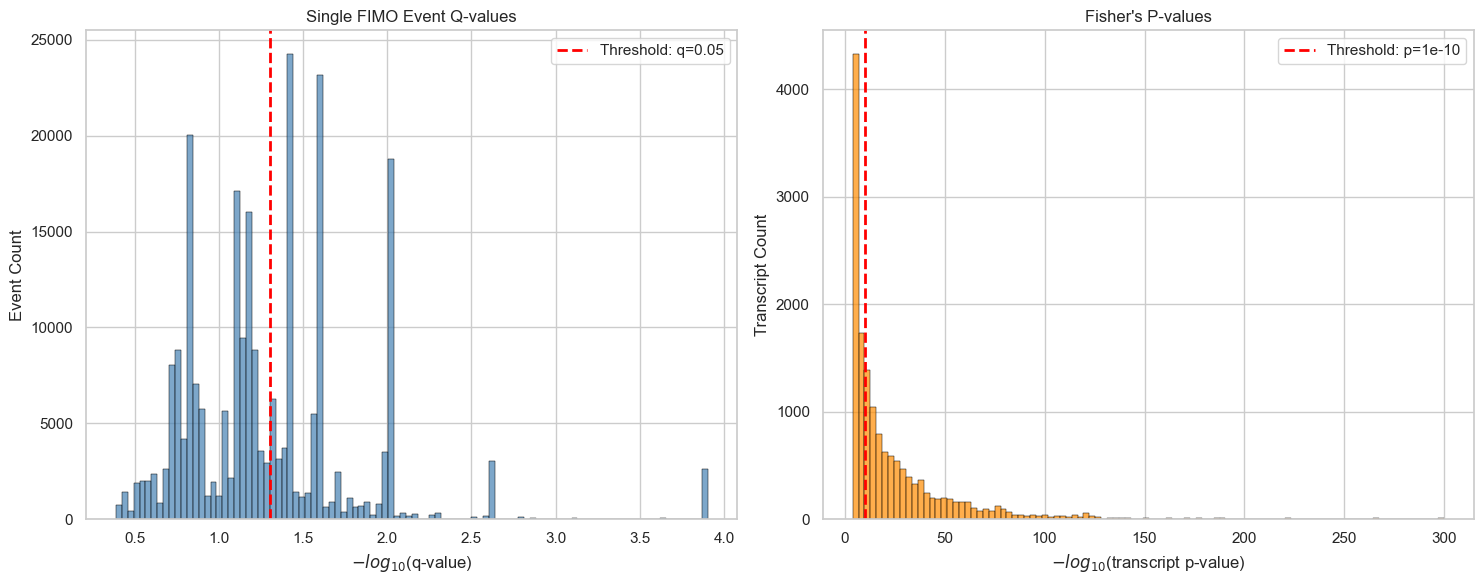

In [38]:
FIMO_Q_THRESH = 0.05
TRANSCRIPT_P_THRESH = 1e-10

# Set seaborn style for cleaner plots
sns.set_theme(style="whitegrid")

# Create a figure with two subplots side-by-side
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Replace absolute zeros to prevent log10(0) domain errors
safe_q_vals = fimo_df['q-value'].replace(0, 1e-300)
neg_log10_q = -np.log10(safe_q_vals)
q_thresh_log = -np.log10(FIMO_Q_THRESH)

sns.histplot(neg_log10_q, bins=100, ax=axes[0], color='steelblue', edgecolor='black', alpha=0.7)
axes[0].axvline(x=q_thresh_log, color='red', linestyle='--', linewidth=2, 
                label=f'Threshold: q={FIMO_Q_THRESH}')

axes[0].set_title('Single FIMO Event Q-values')
axes[0].set_xlabel('$-log_{10}$(q-value)')
axes[0].set_ylabel('Event Count')
axes[0].legend()


safe_p_vals = agg_df['transcript_p_value'].replace(0, 1e-300)
neg_log10_p = -np.log10(safe_p_vals)
p_thresh_log = -np.log10(TRANSCRIPT_P_THRESH)

sns.histplot(neg_log10_p, bins=100, ax=axes[1], color='darkorange', edgecolor='black', alpha=0.7)
axes[1].axvline(x=p_thresh_log, color='red', linestyle='--', linewidth=2, 
                label=f'Threshold: p={TRANSCRIPT_P_THRESH}')

axes[1].set_title("Fisher's P-values")
axes[1].set_xlabel('$-log_{10}$(transcript p-value)')
axes[1].set_ylabel('Transcript Count')
axes[1].legend()

plt.tight_layout()
plt.show()

## Meta Analysis

In [14]:
# Neat filtering (New Pipeline: we only discard transcripts with low expression is all)
import scipy.sparse as sp

In [45]:
# Configuration
variance_matrix_csv = "ATTRACT_3UTR/FIMO_Processed/Isoform_Variance_Matrix.csv"
probabilities_csv = "Main/Probabilities.csv"
output_csv = "ATTRACT_3UTR/FIMO_Processed/Functional_Zipcode_Candidates_new.csv"

ABSOLUTE_CPM_MIN = 1
cell_type_col = "assignments"

print("1. Loading variance matrix and reconstructing Motif Profile...")
df_var = pd.read_csv(variance_matrix_csv)

# Identify all RBP columns dynamically
rbp_columns = df_var.columns.difference(['Gene', 'Transcript']).tolist()

def extract_motifs(row):
    return ", ".join([rbp for rbp in rbp_columns if row[rbp] == 1])

df_var['Motif_Profile'] = df_var.apply(extract_motifs, axis=1)
df_var['Clean_Transcript'] = df_var['Transcript'].str.split('.').str[0]

print("2. Loading probabilities and assigning Macro-SCL Profile...")
df_prob = pd.read_csv(probabilities_csv)


def get_adjusted_scl_profile(row):
    locations = []
    
    # Group nuclear compartments
    nucleus_cols = ['chromatin_prob', 'nucleolus_prob', 'nucleoplasm_prob', 'nucleus_prob']
    if any(row.get(col, 0) > 0.75 for col in nucleus_cols):
        locations.append('Nucleus')
        
    # Group cytoplasmic compartments
    cyto_cols = ['cytoplasm_prob', 'cytosol_prob']
    if any(row.get(col, 0) > 0.75 for col in cyto_cols):
        locations.append('Cytoplasm')
        
    # Independent compartments
    independent_cols = {
        'endoplasmic reticulum_prob': 'Endoplasmic reticulum',
        'extracellular region_prob': 'Extracellular region',
        'membrane_prob': 'Membrane',
        'mitochondrion_prob': 'Mitochondrion',
        'ribosome_prob': 'Ribosome'
    }
    
    for col, name in independent_cols.items():
        if row.get(col, 0) > 0.75:
            locations.append(name)
            
    return ", ".join(locations) if locations else "Unclassified"

# Apply the custom logic to generate the adjusted profile
df_prob['Adjusted_SCL_Profile'] = df_prob.apply(get_adjusted_scl_profile, axis=1)

# Format for merging
df_scl = df_prob[['sequence_id', 'Adjusted_SCL_Profile']].rename(columns={'sequence_id': 'Transcript'})

# Merge profiles
df_combined = pd.merge(df_var, df_scl, on='Transcript', how='left')
df_combined['Adjusted_SCL_Profile'] = df_combined['Adjusted_SCL_Profile'].fillna('Unclassified')

print("3. Reversing log1p and aggregating pseudo-bulk linear profiles...")
if sp.issparse(adata.X):
    raw_counts = adata.X.expm1()
else:
    raw_counts = np.expm1(adata.X)

unique_cell_types = adata.obs[cell_type_col].unique()
cell_type_sums = []

for ct in unique_cell_types:
    cells_mask = (adata.obs[cell_type_col] == ct).values
    ct_sum = np.asarray(raw_counts[cells_mask].sum(axis=0)).flatten()
    cell_type_sums.append(ct_sum)

pseudo_bulk_matrix = np.vstack(cell_type_sums)
library_sizes = pseudo_bulk_matrix.sum(axis=1, keepdims=True)
library_sizes[library_sizes == 0] = 1 
cpm_matrix = (pseudo_bulk_matrix / library_sizes) * 1e6

cpm_df = pd.DataFrame(
    cpm_matrix, 
    index=unique_cell_types, 
    columns=adata.var_names.astype(str).str.split('.').str[0]
)

print(f"4. Applying absolute expression gate (Max CPM >= {ABSOLUTE_CPM_MIN})...")
max_cpm_per_transcript = cpm_df.max(axis=0)

# Identify transcripts passing threshold
valid_transcripts = max_cpm_per_transcript[max_cpm_per_transcript >= ABSOLUTE_CPM_MIN].index

initial_count = len(df_combined)
df_filtered = df_combined[df_combined['Clean_Transcript'].isin(valid_transcripts)].copy()
final_count = len(df_filtered)

print("5. Formatting and saving final output...")
target_columns = ['Gene', 'Transcript', 'Motif_Profile', 'Adjusted_SCL_Profile']
df_filtered = df_filtered[target_columns]

os.makedirs(os.path.dirname(output_csv), exist_ok=True)
df_filtered.to_csv(output_csv, index=False)

print(f"Pipeline complete. Retained {final_count} out of {initial_count} transcripts.")
print(f"New candidate matrix saved to: {output_csv}")

1. Loading variance matrix and reconstructing Motif Profile...
2. Loading probabilities and assigning Macro-SCL Profile...
3. Reversing log1p and aggregating pseudo-bulk linear profiles...
4. Applying absolute expression gate (Max CPM >= 1)...
5. Formatting and saving final output...
Pipeline complete. Retained 932 out of 1172 transcripts.
New candidate matrix saved to: ATTRACT_3UTR/FIMO_Processed/Functional_Zipcode_Candidates_new.csv


### Calculate Cosine Similarity

In [46]:
from sklearn.metrics.pairwise import cosine_similarity
import numpy as np
import pandas as pd

print("1. Extracting raw SCL probability vectors...")
scl_prob_cols = [
    'chromatin_prob', 'nucleolus_prob', 'nucleoplasm_prob', 'nucleus_prob',
    'cytoplasm_prob', 'cytosol_prob', 'endoplasmic reticulum_prob',
    'extracellular region_prob', 'membrane_prob', 'mitochondrion_prob', 'ribosome_prob'
]

# Merge the 11 raw probability columns into your expression-filtered dataset
prob_subset = df_prob[['sequence_id'] + scl_prob_cols].rename(columns={'sequence_id': 'Transcript'})
df_scl_vectors = pd.merge(df_filtered, prob_subset, on='Transcript', how='inner')

print("2. Calculating continuous SCL cosine similarity...")
scl_gene_records = []

for gene, group in df_scl_vectors.groupby('Gene'):
    if len(group) < 2:
        continue
        
    # Extract the raw probability matrix for all transcripts of this gene
    prob_matrix = group[scl_prob_cols].fillna(0).values
    
    # Skip edge cases where all probabilities are completely zero
    if np.sum(prob_matrix) == 0:
        continue
        
    sim_matrix = cosine_similarity(prob_matrix)
    
    upper_tri = sim_matrix[np.triu_indices(len(group), k=1)]
    min_gene_sim = np.min(upper_tri)
    
    scl_gene_records.append({
        'Gene': gene,
        'Min_Raw_SCL_Similarity': min_gene_sim
    })

scl_metrics_df = pd.DataFrame(scl_gene_records)
df_scl_evaluated = pd.merge(df_scl_vectors, scl_metrics_df, on='Gene', how='left')

print(f"Calculated continuous SCL similarities for {len(scl_metrics_df)} multi-transcript genes.")

1. Extracting raw SCL probability vectors...
2. Calculating continuous SCL cosine similarity...
Calculated continuous SCL similarities for 281 multi-transcript genes.


In [12]:
import scanpy as sc

adata = sc.read_h5ad("/home/jingqi/isoforms/adata_thresholded.h5ad")

In [13]:
from sklearn.metrics.pairwise import cosine_similarity
import scipy.sparse as sp
import matplotlib.pyplot as plt
import seaborn as sns

In [14]:
## In order to calculate the SCL similarity, it's better to use the fraction of raw counts, as that could bypass
## absolut value

In [41]:
# Build Pseudo-bulk CPM matrix
cell_type_col = "assignments"
variance_matrix_csv = "ATTRACT_3UTR/FIMO_Processed/Isoform_Variance_Matrix.csv"
matrix_df = pd.read_csv(variance_matrix_csv)

print("Reversing log1p and aggregating pseudo-bulk linear profiles...")
if sp.issparse(adata.X):
    raw_counts = adata.X.expm1()
else:
    raw_counts = np.expm1(adata.X)

unique_cell_types = adata.obs[cell_type_col].unique()
cell_type_sums = []

for ct in unique_cell_types:
    cells_mask = (adata.obs[cell_type_col] == ct).values
    ct_sum = np.asarray(raw_counts[cells_mask].sum(axis=0)).flatten()
    cell_type_sums.append(ct_sum)

pseudo_bulk_matrix = np.vstack(cell_type_sums)
library_sizes = pseudo_bulk_matrix.sum(axis=1, keepdims=True)
library_sizes[library_sizes == 0] = 1 
cpm_matrix = (pseudo_bulk_matrix / library_sizes) * 1e6

cpm_df = pd.DataFrame(
    cpm_matrix, 
    index=unique_cell_types, 
    columns=adata.var_names.astype(str).str.split('.').str[0]
)

print("Calculating geometric similarity on linear fractions...")
gene_min_sims = []
matrix_df['Clean_Transcript'] = matrix_df['Transcript'].str.split('.').str[0]

for gene, group in matrix_df.groupby('Gene'):
    transcripts = group['Clean_Transcript'].values
    if len(transcripts) < 2:
        continue
        
    valid_t = [t for t in transcripts if t in cpm_df.columns]
    if len(valid_t) < 2:
        continue
        
    gene_cpm_matrix = cpm_df[valid_t].values 
    total_gene_cpm = gene_cpm_matrix.sum(axis=1)
    
    valid_mask = total_gene_cpm > 0 
    if valid_mask.sum() == 0:
        continue
        
    valid_cpm = gene_cpm_matrix[valid_mask]
    valid_totals = total_gene_cpm[valid_mask]
    
    fraction_matrix = valid_cpm / valid_totals[:, None]
    transcript_vectors = fraction_matrix.T 
    
    sim_matrix = cosine_similarity(transcript_vectors)
    upper_tri = sim_matrix[np.triu_indices(len(valid_t), k=1)]
    
    if len(upper_tri) > 0:
        gene_min_sims.append(np.min(upper_tri))

Reversing log1p and aggregating pseudo-bulk linear profiles...
Calculating geometric similarity on linear fractions...


Generating diagnostic plot...


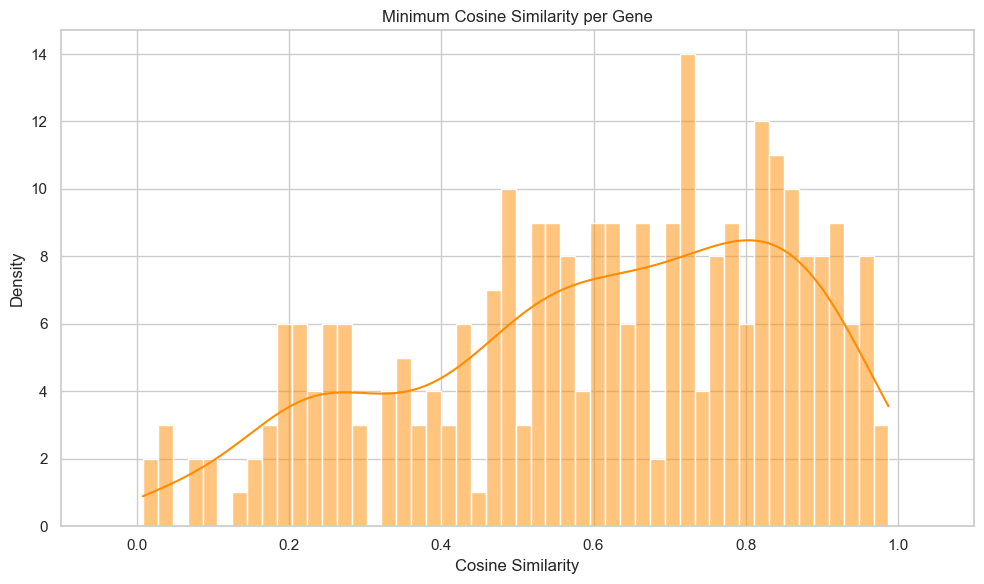

In [42]:
print("Generating diagnostic plot...")
plt.figure(figsize=(10, 6))
sns.set_theme(style="whitegrid")

sns.histplot(gene_min_sims, bins=50, kde=True, color="darkorange")
plt.title("Minimum Cosine Similarity per Gene")
plt.xlabel("Cosine Similarity")
plt.ylabel("Density")
plt.xlim(-0.1, 1.1)

plt.tight_layout()
plt.show()

### Viualization

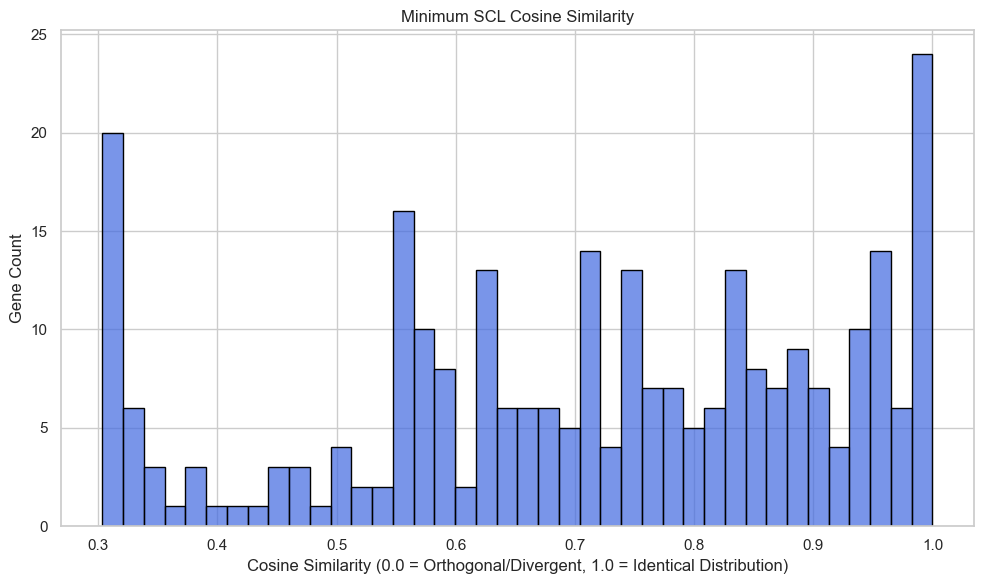

In [49]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
fig, ax = plt.subplots(figsize=(10, 6))

plot_data = scl_metrics_df['Min_Raw_SCL_Similarity'].dropna()

# Using more bins to capture the smooth geometry of the continuous vectors
sns.histplot(plot_data, bins=40, color='royalblue', edgecolor='black', alpha=0.7, ax=ax)

ax.set_title("Minimum SCL Cosine Similarity")
ax.set_xlabel("Cosine Similarity (0.0 = Orthogonal/Divergent, 1.0 = Identical Distribution)")
ax.set_ylabel("Gene Count")

plt.tight_layout()
plt.show()

### Filter by SCL similarity

In [54]:
# Adjust this parameter based on the smooth curve in your new histogram
RAW_SCL_THRESHOLD = 0.85

print(f"Filtering genes with Min Raw-SCL Similarity < {RAW_SCL_THRESHOLD}...")

# Identify the genes that pass the threshold
divergent_scl_genes = scl_metrics_df[scl_metrics_df['Min_Raw_SCL_Similarity'] < RAW_SCL_THRESHOLD]['Gene']
final_scl_divergent_df = df_scl_evaluated[df_scl_evaluated['Gene'].isin(divergent_scl_genes)].copy()

# Sort the dataframe using the mathematical similarity (most divergent first)
final_scl_divergent_df.sort_values(by=['Min_Raw_SCL_Similarity', 'Gene'], ascending=[True, True], inplace=True)

# Restrict to EXACTLY the four columns in your target format
target_columns = ['Gene', 'Transcript', 'Motif_Profile', 'Adjusted_SCL_Profile']
final_output_df = final_scl_divergent_df[target_columns]

# Export to match your requested file structure
final_csv_path = "ATTRACT_3UTR/FIMO_Processed/Functional_Zipcode_Candidates_new.csv"
final_output_df.to_csv(final_csv_path, index=False)

print(f"Genes passing Raw-SCL divergence threshold: {final_scl_divergent_df['Gene'].nunique()}")
print(f"Final target matrix saved to: {final_csv_path}")

Filtering genes with Min Raw-SCL Similarity < 0.85...
Genes passing Raw-SCL divergence threshold: 197
Final target matrix saved to: ATTRACT_3UTR/FIMO_Processed/Functional_Zipcode_Candidates_new.csv
